# Customer Review Handler — Conditional LLM Workflow

**Graph:** START → find_sentiment → [positive_response → END | run_diagnosis → negative_response → END]

**Key concepts:**
1. `add_conditional_edges` — routing function returns a node name string
2. Structured output for classification (sentiment, diagnosis)
3. Different branches for positive vs negative reviews

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_community.llms.fake import FakeListLLM
from pydantic import BaseModel, Field
from typing import TypedDict, Optional, Literal
from dotenv import load_dotenv

load_dotenv()

C:\Users\Deepika Yadav\AppData\Local\Temp\ipykernel_34804\112563903.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.llms.fake import FakeListLLM


True

## Step 1 — Structured Output Schemas

In [2]:
class SentimentSchema(BaseModel):
    sentiment: Literal['positive', 'negative'] = Field(
        description='Sentiment of the customer review'
    )


class DiagnosisSchema(BaseModel):
    issue_type: Literal['ux', 'performance', 'bug', 'support', 'other'] = Field(
        description='Category of the issue raised in the review'
    )
    tonality: Literal['frustrated', 'angry', 'neutral', 'disappointed', 'other'] = Field(
        description='Emotional tone of the reviewer'
    )
    urgency: Literal['low', 'medium', 'high'] = Field(
        description='How urgently the issue needs to be addressed'
    )

## Step 2 — Mock Models

Three mocks replace real LLM calls:
- `MockSentimentModel` — classifies positive/negative by checking keywords
- `MockDiagnosisModel` — returns a predefined `DiagnosisSchema` object
- `positive_model` / `negative_model` — `FakeListLLM` for plain-text responses

In [3]:
class MockSentimentModel:
    """Checks review for positive keywords; falls back to negative."""
    _POSITIVE_WORDS = [
        'love', 'great', 'excellent', 'amazing', 'good',
        'best', 'perfect', 'awesome', 'happy', 'fantastic'
    ]

    def invoke(self, prompt: str):
        lower = prompt.lower()
        if any(w in lower for w in self._POSITIVE_WORDS):
            return SentimentSchema(sentiment='positive')
        return SentimentSchema(sentiment='negative')


class MockDiagnosisModel:
    """Returns a fixed diagnosis — swap logic here to vary by keyword."""
    def invoke(self, prompt: str):
        lower = prompt.lower()
        if 'slow' in lower or 'lag' in lower or 'loading' in lower:
            return DiagnosisSchema(issue_type='performance', tonality='frustrated', urgency='medium')
        if 'crash' in lower or 'bug' in lower or 'error' in lower or 'freeze' in lower:
            return DiagnosisSchema(issue_type='bug', tonality='angry', urgency='high')
        if 'hard to use' in lower or 'confusing' in lower or 'unclear' in lower:
            return DiagnosisSchema(issue_type='ux', tonality='disappointed', urgency='medium')
        return DiagnosisSchema(issue_type='support', tonality='frustrated', urgency='low')


sentiment_model = MockSentimentModel()
diagnosis_model = MockDiagnosisModel()

positive_model = FakeListLLM(responses=[
    'Thank you so much for your wonderful review! We are thrilled to hear '
    'that you are enjoying the experience. Your feedback motivates us to keep '
    'improving. Please do share your experience with friends and family!',
    'We really appreciate your kind words! Knowing that our product is making '
    'a positive difference means everything to us. Thank you for being an '
    'amazing customer!',
])

negative_model = FakeListLLM(responses=[
    'We sincerely apologize for the inconvenience you have experienced. '
    'Your feedback is extremely valuable and has been escalated to our technical team. '
    'We are working urgently to resolve this issue and will follow up shortly. '
    'Please contact support@app.com for immediate assistance.',
    'We are sorry to hear about your experience. We take all feedback seriously '
    'and our team is already looking into this issue. Thank you for bringing '
    'this to our attention — we will make it right.',
])

print('Models ready!')

Models ready!


## Step 3 — Define State

In [4]:
class ReviewState(TypedDict):
    review: str
    sentiment: Optional[str]
    diagnosis: Optional[dict]    # keys: issue_type, tonality, urgency
    response: Optional[str]

## Step 4 — Define Nodes

In [5]:
def find_sentiment(state: ReviewState) -> dict:
    prompt = f'Classify the sentiment of this customer review:\n{state["review"]}'
    output = sentiment_model.invoke(prompt)
    return {'sentiment': output.sentiment}


def positive_response(state: ReviewState) -> dict:
    prompt = f'Write a warm thank-you response to this positive review:\n{state["review"]}'
    response = positive_model.invoke(prompt)
    return {'response': response}


def run_diagnosis(state: ReviewState) -> dict:
    prompt = (
        f'Analyze this negative review. Identify the issue type, '
        f'emotional tonality, and urgency:\n{state["review"]}'
    )
    output = diagnosis_model.invoke(prompt)
    return {
        'diagnosis': {
            'issue_type': output.issue_type,
            'tonality': output.tonality,
            'urgency': output.urgency,
        }
    }


def negative_response(state: ReviewState) -> dict:
    diag = state['diagnosis']
    prompt = (
        f'Write an empathetic support response to this negative review.\n'
        f'Review: {state["review"]}\n'
        f'Issue type: {diag["issue_type"]} | '
        f'Tonality: {diag["tonality"]} | '
        f'Urgency: {diag["urgency"]}'
    )
    response = negative_model.invoke(prompt)
    return {'response': response}

## Step 5 — Routing Function

Not a node — called by `add_conditional_edges` to decide the next node.

In [6]:
def check_sentiment(state: ReviewState) -> str:
    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

## Step 6 — Build Graph

In [7]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

# Sequential edge into the classifier
graph.add_edge(START, 'find_sentiment')

# Conditional edge — routing function decides the branch
graph.add_conditional_edges('find_sentiment', check_sentiment)

# Positive branch → END
graph.add_edge('positive_response', END)

# Negative branch: diagnosis → response → END
graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()
print('Graph compiled successfully!')

Graph compiled successfully!


## Step 7 — Visualise (dotted lines = conditional branch)

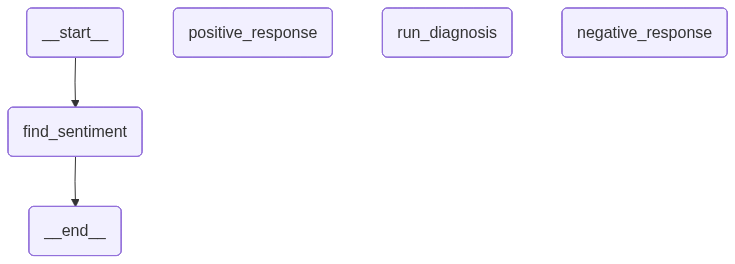

In [8]:
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

## Step 8 — Execute

### Case 1: Positive review → short thank-you

In [9]:
positive_review = (
    'I absolutely love this app! The interface is clean, everything loads fast, '
    'and the new features are amazing. Best productivity app I have used. '
    'Great job to the entire team!'
)

state1 = {'review': positive_review, 'sentiment': None, 'diagnosis': None, 'response': None}
out1 = workflow.invoke(state1)

print('Review   :', out1['review'])
print('Sentiment:', out1['sentiment'])
print('Diagnosis:', out1['diagnosis'])
print('\nResponse :')
print(out1['response'])

Review   : I absolutely love this app! The interface is clean, everything loads fast, and the new features are amazing. Best productivity app I have used. Great job to the entire team!
Sentiment: positive
Diagnosis: None

Response :
Thank you so much for your wonderful review! We are thrilled to hear that you are enjoying the experience. Your feedback motivates us to keep improving. Please do share your experience with friends and family!


### Case 2: Negative review → diagnosis → empathetic response

In [10]:
# Reset FakeListLLM indices
negative_model.responses = negative_model.responses  # no-op, index auto-cycles

negative_review = (
    'The app keeps crashing every time I try to open a document. '
    'This bug has been there for two weeks and nothing has been fixed. '
    'Very frustrating — I cannot do any work at all. Please fix this immediately!'
)

state2 = {'review': negative_review, 'sentiment': None, 'diagnosis': None, 'response': None}
out2 = workflow.invoke(state2)

print('Review   :', out2['review'])
print('Sentiment:', out2['sentiment'])
print('Diagnosis:', out2['diagnosis'])
print('\nResponse :')
print(out2['response'])

Review   : The app keeps crashing every time I try to open a document. This bug has been there for two weeks and nothing has been fixed. Very frustrating — I cannot do any work at all. Please fix this immediately!
Sentiment: negative
Diagnosis: {'issue_type': 'bug', 'tonality': 'angry', 'urgency': 'high'}

Response :
We sincerely apologize for the inconvenience you have experienced. Your feedback is extremely valuable and has been escalated to our technical team. We are working urgently to resolve this issue and will follow up shortly. Please contact support@app.com for immediate assistance.


### Case 3: Performance complaint

In [11]:
perf_review = (
    'The app is painfully slow. Everything takes forever to load '
    'and there is constant lag. My phone is new so it is not a device issue. '
    'Please optimise the performance.'
)

state3 = {'review': perf_review, 'sentiment': None, 'diagnosis': None, 'response': None}
out3 = workflow.invoke(state3)

print('Sentiment:', out3['sentiment'])
print('Diagnosis:', out3['diagnosis'])
print('\nResponse :')
print(out3['response'])

Sentiment: negative
Diagnosis: {'issue_type': 'performance', 'tonality': 'frustrated', 'urgency': 'medium'}

Response :
We are sorry to hear about your experience. We take all feedback seriously and our team is already looking into this issue. Thank you for bringing this to our attention — we will make it right.
